# Complementary simulation study

## Mixed setting with global program and cell-type-specific program

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator

try:
    import libpysal, esda
    from libpysal.weights import KNN
    HAVE_ESDA = True
except Exception:
    HAVE_ESDA = False
    print("esda/libpysal not found -> spatial coherence falls back to |corr|")

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "axes.linewidth": 0.8,
    "font.size": 13, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.edgecolor": "#333333", "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})
TITLE_FS = 15; CBAR_FS = 9; BAR_TICK_FS = 10

In [2]:
RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shared_new"
FIG_DIR  = "/import/home2/share/yqzeng/MacSGP/revision_2/vis/2.2/figs/mixed_panel"
IND_DIR  = os.path.join(FIG_DIR, "individual")
os.makedirs(IND_DIR, exist_ok=True)

SCN = "S2_mixed"
BASELINES = ["nmf", "mofa", "stamp", "spicemix"]
METHODS = ["macsgp"] + BASELINES
PROP_THRESH = 0.10
CMAP = "bwr"       # factor maps
PROP_CMAP = "YlOrBr"    # proportion (yellow)

PALETTE = {"nmf": "#CCB974", "mofa": "#55A868", "spicemix": "#C44E52", "stamp": "#8172B3", "macsgp": "#4C72B0"}
LABEL   = {"nmf": "NMF", "mofa": "MOFA", "spicemix": "SpiceMix", "stamp": "STAMP", "macsgp": "MacSGP"}
ORDER   = ["nmf", "mofa", "spicemix", "stamp", "macsgp"]

def _sub(m): return {"nmf":"NMF","mofa":"MOFA","stamp":"stamp","spicemix":"spicemix"}[m]
def factor_path(m):  return os.path.join(RESULT_PATH, _sub(m), f"factors_{SCN}.csv")
def loading_path(m): return os.path.join(RESULT_PATH, _sub(m), f"loadings_{SCN}.csv")

In [3]:
def _corr(a, b):
    a=np.asarray(a,float).ravel(); b=np.asarray(b,float).ravel()
    return 0.0 if a.std()==0 or b.std()==0 else float(np.corrcoef(a,b)[0,1])

def spatial_coherence(f_true, f_rec, coords, mask, k=9):
    a=np.asarray(f_true).ravel()[mask]; b=np.asarray(f_rec).ravel()[mask]
    if a.std()==0 or b.std()==0: return 0.0
    if HAVE_ESDA:
        w=KNN.from_array(coords[mask], k=k); w.transform='r'
        return abs(esda.Moran_BV(a,b,w,permutations=0).I)
    return abs(_corr(a,b))

def macsgp_components(adata, celltypes):
    out={}
    if 'factor' in adata.obsm:
        for ct in celltypes:
            out[f"{ct}.SGP0"]=(adata.obsm['factor'][ct].values.ravel(), adata.varm['loading'][ct].values.ravel())
    for ct in celltypes:
        if ct in adata.obsm:
            F=np.asarray(adata.obsm[ct]); L=np.asarray(adata.varm[ct])
            for j in range(F.shape[1]):
                if np.linalg.norm(L[:,j])>1e-8:
                    out[f"{ct}.SGP{j}"]=(F[:,j], L[:,j])
    return out

def clip99(v):
    v=np.asarray(v,float).ravel()
    lo,hi=np.percentile(v,[1,99])
    if hi<=lo: hi=lo+1e-9
    return np.clip(v,lo,hi), lo, hi

In [4]:
# ---- load S2_mixed ----
adata = sc.read_h5ad(os.path.join(RESULT_PATH, f"adata_result_macsgp_{SCN}.h5ad"))
coords = np.asarray(adata.obsm['spatial'])
celltypes = list(adata.obsm['proportion'].columns)
prop0 = np.asarray(adata.obsm['proportion']['celltype_0']).ravel()
prop1 = np.asarray(adata.obsm['proportion']['celltype_1']).ravel()

programs={}
gf=np.asarray(adata.obsm['global_factor']); gl=np.asarray(adata.varm['global_loading'])
for r in range(gf.shape[1]):
    programs[f"shared{r}"]=dict(f=gf[:,r], l=gl[:,r], mask=np.ones(adata.n_obs,bool))
sf=adata.obsm['simulated_factor']; sl=np.asarray(adata.varm['simulated_loading'])
for i,ct in enumerate(sf.columns):
    programs[f"specific[{ct}]"]=dict(f=np.asarray(sf[ct]).ravel(), l=sl[:,i], mask=prop0>PROP_THRESH)

macsgp=macsgp_components(adata, celltypes)
base={}
for m in BASELINES:
    fdf=pd.read_csv(factor_path(m), index_col=0).reindex(adata.obs_names)
    ldf=pd.read_csv(loading_path(m), index_col=0).reindex(adata.var_names, fill_value=0.0)
    base[m]=(fdf, ldf)
print("programs:", list(programs), "| macsgp:", list(macsgp))

programs: ['shared0', 'specific[celltype_0]'] | macsgp: ['celltype_0.SGP0', 'celltype_0.SGP1', 'celltype_1.SGP0']


In [5]:
SEL = {
    "shared0":              {"macsgp":"celltype_0.SGP0","nmf":0,"mofa":0,"stamp":1,"spicemix":3},
    "specific[celltype_0]": {"macsgp":"celltype_0.SGP1","nmf":1,"mofa":1,"stamp":2,"spicemix":4},
}
def get_component(method, selector):
    if method=="macsgp": return macsgp[selector]
    fdf,ldf=base[method]; j=int(selector)
    return fdf.iloc[:,j].values.ravel(), ldf.iloc[:,j].values.ravel()

rows=[]
for prog,pinfo in programs.items():
    f_true,l_true,mask=pinfo['f'],pinfo['l'],pinfo['mask']
    for m in [x for x in METHODS if x in SEL.get(prog,{})]:
        f_rec,l_rec=get_component(m, SEL[prog][m])
        rows.append({"program":prog,"method":m,
                     "spatial_coherence":round(spatial_coherence(f_true,f_rec,coords,mask),3),
                     "program_coherence":round(abs(_corr(l_rec,l_true)),3)})
metrics=pd.DataFrame(rows); metrics.to_csv(os.path.join(FIG_DIR,"metrics_selected.csv"), index=False)
def _val(prog, method, metric):
    r=metrics[(metrics.program==prog)&(metrics.method==method)]
    return abs(float(r[metric].iloc[0])) if len(r) else 0.0
print(metrics.to_string(index=False))

             program   method  spatial_coherence  program_coherence
             shared0   macsgp              0.939              0.971
             shared0      nmf              0.898              0.837
             shared0     mofa              0.955              0.951
             shared0    stamp              0.760              0.573
             shared0 spicemix              0.745              0.572
specific[celltype_0]   macsgp              0.921              0.845
specific[celltype_0]      nmf              0.733              0.479
specific[celltype_0]     mofa              0.065              0.040
specific[celltype_0]    stamp              0.741              0.433
specific[celltype_0] spicemix              0.825              0.778

In [ ]:
g_true = programs["shared0"]["f"]; s_true = programs["specific[celltype_0]"]["f"]
def base_fac(m, prog): return get_component(m, SEL[prog][m])[0]

PANELS = [
 (0,0,"spatial", dict(v=prop0,  sign=None,   cmap=PROP_CMAP, title="",   tag="ct1_prop")),
 (0,1,"spatial", dict(v=g_true, sign=None,   cmap=CMAP, title="",     tag="global_true")),
 (0,2,"spatial", dict(v=s_true, sign=None,   cmap=CMAP, title="",   tag="specific_true")),
 (0,3,"spatial", dict(v=macsgp["celltype_0.SGP0"][0], sign=g_true, cmap=CMAP, title="", tag="macsgp_ct1_sgp0")),
 (0,4,"spatial", dict(v=macsgp["celltype_0.SGP1"][0], sign=s_true, cmap=CMAP, title="", tag="macsgp_ct1_sgp1")),
 (0,5,"spatial", dict(v=macsgp["celltype_1.SGP0"][0], sign=prop1,  cmap=CMAP, title="", tag="macsgp_ct2_sgp0")),
 (1,0,"spatial", dict(v=base_fac("nmf","shared0"),      sign=g_true, cmap=CMAP, title="",      tag="global_nmf")),
 (1,1,"spatial", dict(v=base_fac("mofa","shared0"),     sign=g_true, cmap=CMAP, title="",     tag="global_mofa")),
 (1,3,"spatial", dict(v=base_fac("stamp","shared0"),    sign=g_true, cmap=CMAP, title="",    tag="global_stamp")),
 (1,2,"spatial", dict(v=base_fac("spicemix","shared0"), sign=g_true, cmap=CMAP, title="", tag="global_spicemix")),
 (1,4,"bar",     dict(prog="shared0", metric="spatial_coherence", title="", tag="global_bar_spatial")),
 (1,5,"bar",     dict(prog="shared0", metric="program_coherence", title="", tag="global_bar_program")),
 (2,0,"spatial", dict(v=base_fac("nmf","specific[celltype_0]"),      sign=s_true, cmap=CMAP, title="",      tag="specific_nmf")),
 (2,1,"spatial", dict(v=base_fac("mofa","specific[celltype_0]"),     sign=s_true, cmap=CMAP, title="",     tag="specific_mofa")),
 (2,3,"spatial", dict(v=base_fac("stamp","specific[celltype_0]"),    sign=s_true, cmap=CMAP, title="",    tag="specific_stamp")),
 (2,2,"spatial", dict(v=base_fac("spicemix","specific[celltype_0]"), sign=s_true, cmap=CMAP, title="", tag="specific_spicemix")),
 (2,4,"bar",     dict(prog="specific[celltype_0]", metric="spatial_coherence", title="", tag="specific_bar_spatial")),
 (2,5,"bar",     dict(prog="specific[celltype_0]", metric="program_coherence", title="", tag="specific_bar_program")),
]

def add_cbar(ax, sm, ticks, label):
    cax = ax.inset_axes([0.25, -0.15, 0.5, 0.045])   # half-width, centered, below the panel
    cb = ax.figure.colorbar(sm, cax=cax, orientation="horizontal")
    if ticks:
        cb.locator = MaxNLocator(nbins=3); cb.update_ticks(); cax.tick_params(labelsize=CBAR_FS)
    else:
        cb.set_ticks([])
    if label:
        cb.set_label(label, fontsize=CBAR_FS, labelpad=2)
    return cb

def draw_spatial(ax, v, sign, cmap, normalize, cbar_ticks, cbar_label, title=None, spot=6):
    vv=np.asarray(v,float).ravel()
    if sign is not None and _corr(vv,sign)<0: vv=-vv
    vc,lo,hi=clip99(vv)
    if normalize:
        vc=(vc-lo)/(hi-lo+1e-12); lo,hi=0.0,1.0
    sm=ax.scatter(coords[:,0],coords[:,1],c=vc,cmap=cmap,s=spot,vmin=lo,vmax=hi,linewidths=0)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    if title: ax.set_title(title, fontsize=TITLE_FS)
    add_cbar(ax, sm, cbar_ticks, cbar_label)
    return sm

def draw_bar(ax, prog, metric, title=None):
    vals=[_val(prog,m,metric) for m in ORDER]
    ax.bar(range(len(ORDER)), vals, color=[PALETTE[m] for m in ORDER])
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels([LABEL[m] for m in ORDER], rotation=45, ha="right", fontsize=BAR_TICK_FS)
    ax.set_ylim(0,1); ax.tick_params(axis="y", labelsize=CBAR_FS); ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if title: ax.set_title(title, fontsize=TITLE_FS)

def render(ax, kind, p):
    if kind=="spatial":
        is_prop = (p["tag"]=="ct1_prop")
        draw_spatial(ax, p["v"], p["sign"], p["cmap"], normalize=(not is_prop),
                     cbar_ticks=is_prop, cbar_label=(None if is_prop else "Normalized score"),
                     title=p.get("title"))
    else:
        draw_bar(ax, p["prog"], p["metric"], p.get("title"))

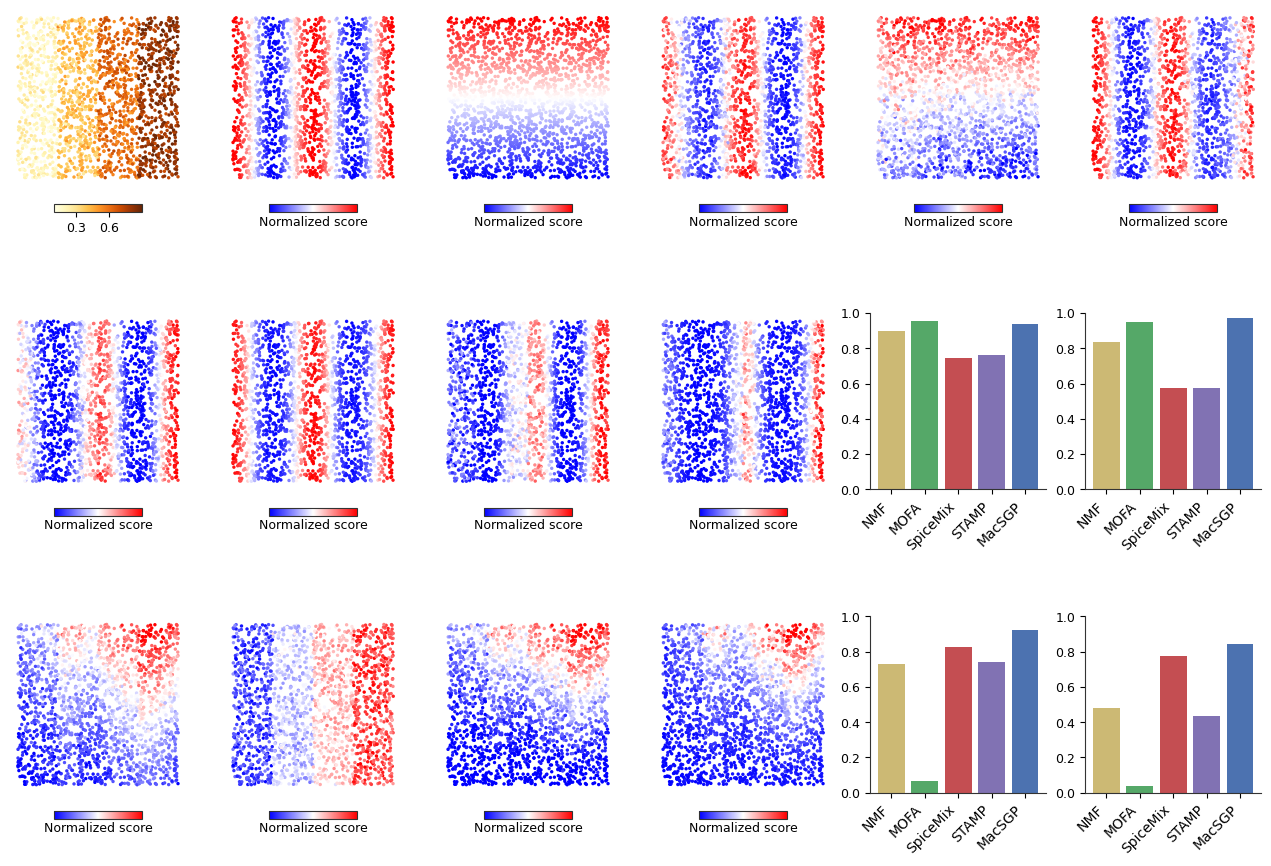

composite saved


In [7]:
fig, axes = plt.subplots(3, 6, figsize=(6*2.15, 3*2.95))
for r,c,kind,p in PANELS:
    render(axes[r][c], kind, p)
fig.subplots_adjust(left=0.02, right=0.99, top=0.93, bottom=0.03, wspace=0.22, hspace=0.60)
fig.savefig(os.path.join(FIG_DIR,"mixed_panel_composite.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR,"mixed_panel_composite.png"), dpi=200, bbox_inches="tight")
plt.show(); print("composite saved")

In [8]:
for r,c,kind,p in PANELS:
    stem=os.path.join(IND_DIR, f"r{r+1}c{c+1}_{p['tag']}")
    if kind=="spatial":
        f,ax=plt.subplots(figsize=(2.8,3.1))
        is_prop=(p["tag"]=="ct1_prop")
        draw_spatial(ax, p["v"], p["sign"], p["cmap"], normalize=(not is_prop),
                     cbar_ticks=is_prop, cbar_label=(None if is_prop else "Normalized scores"),
                     title=None, spot=18)
        f.savefig(stem+".pdf", bbox_inches="tight", transparent=True)
        f.savefig(stem+".png", dpi=200, bbox_inches="tight", transparent=True); plt.close(f)
    else:
        f,ax=plt.subplots(figsize=(3.0,3.2))
        draw_bar(ax, p["prog"], p["metric"], title=p["title"])
        f.savefig(stem+".pdf", bbox_inches="tight"); f.savefig(stem+".png", dpi=200, bbox_inches="tight"); plt.close(f)
print("individual panels ->", IND_DIR)

individual panels -> /import/home2/share/yqzeng/MacSGP/revision_2/vis/2.2/figs/mixed_panel/individual


## Negative control setting with only global program

In [ ]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator

try:
    import libpysal, esda
    from libpysal.weights import KNN
    HAVE_ESDA = True
except Exception:
    HAVE_ESDA = False
    print("esda/libpysal not found -> spatial coherence falls back to |corr|")

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "axes.linewidth": 0.8,
    "font.size": 13, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.edgecolor": "#333333", "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})
TITLE_FS = 15; CBAR_FS = 9; BAR_TICK_FS = 10

In [ ]:
RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shared_new"
FIG_DIR  = "/import/home2/share/yqzeng/MacSGP/revision_2/vis/2.2/figs/neg_panel"
IND_DIR  = os.path.join(FIG_DIR, "individual")
os.makedirs(IND_DIR, exist_ok=True)

SCN = "S3_neg"
BASELINES = ["nmf", "mofa", "stamp", "spicemix"]
METHODS = ["macsgp"] + BASELINES
PROP_THRESH = 0.10
CMAP = "bwr"            # factor maps
PROP_CMAP = "YlOrBr"    # proportion (yellow)

PALETTE = {"nmf": "#CCB974", "mofa": "#55A868", "spicemix": "#C44E52", "stamp": "#8172B3", "macsgp": "#4C72B0"}
LABEL   = {"nmf": "NMF", "mofa": "MOFA", "spicemix": "SpiceMix", "stamp": "STAMP", "macsgp": "MacSGP"}
ORDER   = ["nmf", "mofa", "spicemix", "stamp", "macsgp"]

def _sub(m): return {"nmf":"NMF","mofa":"MOFA","stamp":"stamp","spicemix":"spicemix"}[m]
def factor_path(m):  return os.path.join(RESULT_PATH, _sub(m), f"factors_{SCN}.csv")
def loading_path(m): return os.path.join(RESULT_PATH, _sub(m), f"loadings_{SCN}.csv")

In [ ]:
def _corr(a, b):
    a=np.asarray(a,float).ravel(); b=np.asarray(b,float).ravel()
    return 0.0 if a.std()==0 or b.std()==0 else float(np.corrcoef(a,b)[0,1])

def spatial_coherence(f_true, f_rec, coords, mask, k=9):
    a=np.asarray(f_true).ravel()[mask]; b=np.asarray(f_rec).ravel()[mask]
    if a.std()==0 or b.std()==0: return 0.0
    if HAVE_ESDA:
        w=KNN.from_array(coords[mask], k=k); w.transform='r'
        return abs(esda.Moran_BV(a,b,w,permutations=0).I)
    return abs(_corr(a,b))

def macsgp_components(adata, celltypes):
    out={}
    if 'factor' in adata.obsm:
        for ct in celltypes:
            out[f"{ct}.SGP0"]=(adata.obsm['factor'][ct].values.ravel(), adata.varm['loading'][ct].values.ravel())
    for ct in celltypes:
        if ct in adata.obsm:
            F=np.asarray(adata.obsm[ct]); L=np.asarray(adata.varm[ct])
            for j in range(F.shape[1]):
                if np.linalg.norm(L[:,j])>1e-8:
                    out[f"{ct}.SGP{j}"]=(F[:,j], L[:,j])
    return out

def clip99(v):
    v=np.asarray(v,float).ravel()
    lo,hi=np.percentile(v,[1,99])
    if hi<=lo: hi=lo+1e-9
    return np.clip(v,lo,hi), lo, hi

In [ ]:
# ---- load S3_neg ----
adata = sc.read_h5ad(os.path.join(RESULT_PATH, f"adata_result_macsgp_{SCN}.h5ad"))
coords = np.asarray(adata.obsm['spatial'])
celltypes = list(adata.obsm['proportion'].columns)
prop0 = np.asarray(adata.obsm['proportion']['celltype_0']).ravel()
prop1 = np.asarray(adata.obsm['proportion']['celltype_1']).ravel()

programs={}
gf=np.asarray(adata.obsm['global_factor']); gl=np.asarray(adata.varm['global_loading'])
for r in range(gf.shape[1]):
    programs[f"shared{r}"]=dict(f=gf[:,r], l=gl[:,r], mask=np.ones(adata.n_obs,bool))

macsgp=macsgp_components(adata, celltypes)
base={}
for m in BASELINES:
    fdf=pd.read_csv(factor_path(m), index_col=0).reindex(adata.obs_names)
    ldf=pd.read_csv(loading_path(m), index_col=0).reindex(adata.var_names, fill_value=0.0)
    base[m]=(fdf, ldf)
print("programs:", list(programs), "| macsgp:", list(macsgp))

programs: ['shared0'] | macsgp: ['celltype_0.SGP0', 'celltype_1.SGP0']


In [ ]:
SEL = {"shared0": {"macsgp":"celltype_0.SGP0","nmf":0,"mofa":0,"stamp":4,"spicemix":0}}
def get_component(method, selector):
    if method=="macsgp": return macsgp[selector]
    fdf,ldf=base[method]; j=int(selector)
    return fdf.iloc[:,j].values.ravel(), ldf.iloc[:,j].values.ravel()

rows=[]
for prog,pinfo in programs.items():
    f_true,l_true,mask=pinfo['f'],pinfo['l'],pinfo['mask']
    for m in [x for x in METHODS if x in SEL.get(prog,{})]:
        f_rec,l_rec=get_component(m, SEL[prog][m])
        rows.append({"program":prog,"method":m,
                     "spatial_coherence":round(spatial_coherence(f_true,f_rec,coords,mask),3),
                     "program_coherence":round(abs(_corr(l_rec,l_true)),3)})
metrics=pd.DataFrame(rows); metrics.to_csv(os.path.join(FIG_DIR,"metrics_selected.csv"), index=False)
def _val(prog, method, metric):
    r=metrics[(metrics.program==prog)&(metrics.method==method)]
    return abs(float(r[metric].iloc[0])) if len(r) else 0.0
print(metrics.to_string(index=False))

program   method  spatial_coherence  program_coherence
shared0   macsgp              0.931              0.978
shared0      nmf              0.900              0.851
shared0     mofa              0.956              0.960
shared0    stamp              0.852              0.939
shared0 spicemix              0.716              0.589


In [ ]:
g_true = programs["shared0"]["f"]
def base_fac(m, prog): return get_component(m, SEL[prog][m])[0]

PANELS = [
 (0,0,"spatial", dict(v=prop0,  sign=None,  cmap=PROP_CMAP, title="", tag="ct1_prop")),
 (0,1,"spatial", dict(v=g_true, sign=None,  cmap=CMAP, title="", tag="global_true")),
 (0,2,"spatial", dict(v=macsgp["celltype_0.SGP0"][0], sign=g_true, cmap=CMAP, title="", tag="macsgp_ct1_sgp0")),
 (0,3,"spatial", dict(v=macsgp["celltype_1.SGP0"][0], sign=prop1,  cmap=CMAP, title="", tag="macsgp_ct2_sgp0")),
 (0,4,"bar",     dict(prog="shared0", metric="spatial_coherence", title="", tag="global_bar_spatial")),
 (1,0,"spatial", dict(v=base_fac("nmf","shared0"),      sign=g_true, cmap=CMAP, title="", tag="global_nmf")),
 (1,1,"spatial", dict(v=base_fac("mofa","shared0"),     sign=g_true, cmap=CMAP, title="", tag="global_mofa")),
 (1,3,"spatial", dict(v=base_fac("stamp","shared0"),    sign=g_true, cmap=CMAP, title="", tag="global_stamp")),
 (1,2,"spatial", dict(v=base_fac("spicemix","shared0"), sign=g_true, cmap=CMAP, title="", tag="global_spicemix")),
 (1,4,"bar",     dict(prog="shared0", metric="program_coherence", title="", tag="global_bar_program")),
]

def add_cbar(ax, sm, ticks, label):
    cax = ax.inset_axes([0.25, -0.15, 0.5, 0.045])   # half-width, centered, below the panel
    cb = ax.figure.colorbar(sm, cax=cax, orientation="horizontal")
    if ticks:
        cb.locator = MaxNLocator(nbins=3); cb.update_ticks(); cax.tick_params(labelsize=CBAR_FS)
    else:
        cb.set_ticks([])
    if label:
        cb.set_label(label, fontsize=CBAR_FS, labelpad=2)
    return cb

def draw_spatial(ax, v, sign, cmap, normalize, cbar_ticks, cbar_label, title=None, spot=6):
    vv=np.asarray(v,float).ravel()
    if sign is not None and _corr(vv,sign)<0: vv=-vv
    vc,lo,hi=clip99(vv)
    if normalize:
        vc=(vc-lo)/(hi-lo+1e-12); lo,hi=0.0,1.0
    sm=ax.scatter(coords[:,0],coords[:,1],c=vc,cmap=cmap,s=spot,vmin=lo,vmax=hi,linewidths=0)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    if title: ax.set_title(title, fontsize=TITLE_FS)
    add_cbar(ax, sm, cbar_ticks, cbar_label)
    return sm

def draw_bar(ax, prog, metric, title=None):
    vals=[_val(prog,m,metric) for m in ORDER]
    ax.bar(range(len(ORDER)), vals, color=[PALETTE[m] for m in ORDER])
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels([LABEL[m] for m in ORDER], rotation=45, ha="right", fontsize=BAR_TICK_FS)
    ax.set_ylim(0,1); ax.tick_params(axis="y", labelsize=CBAR_FS); ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if title: ax.set_title(title, fontsize=TITLE_FS)

def render(ax, kind, p):
    if kind=="spatial":
        is_prop = (p["tag"]=="ct1_prop")
        draw_spatial(ax, p["v"], p["sign"], p["cmap"], normalize=(not is_prop),
                     cbar_ticks=is_prop, cbar_label=(None if is_prop else "Normalized score"),
                     title=p.get("title"))
    else:
        draw_bar(ax, p["prog"], p["metric"], p.get("title"))

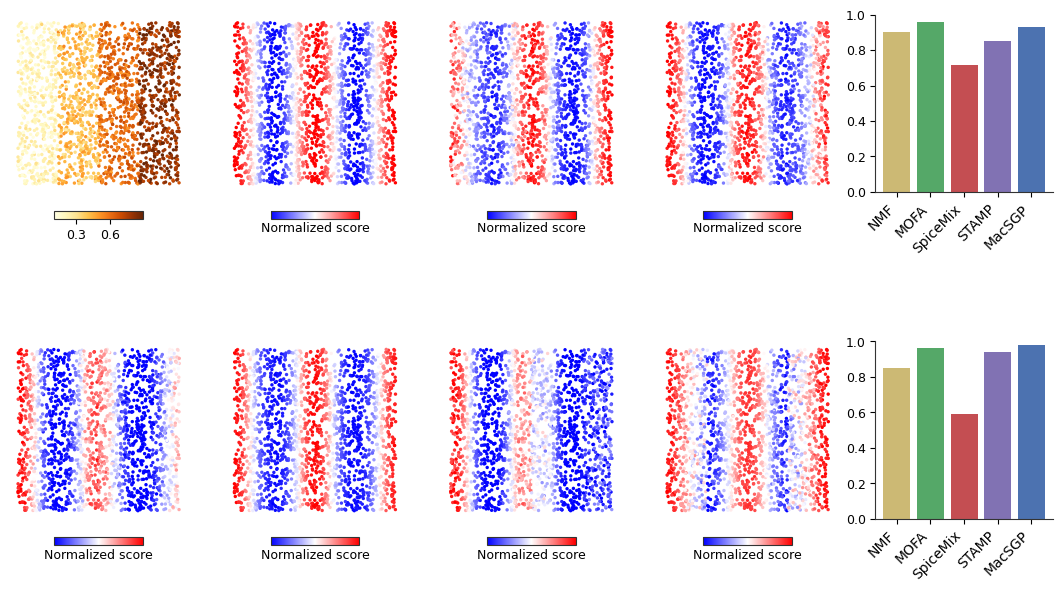

composite saved


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(5*2.15, 2*2.95))
for r,c,kind,p in PANELS:
    render(axes[r][c], kind, p)
fig.subplots_adjust(left=0.02, right=0.99, top=0.93, bottom=0.03, wspace=0.22, hspace=0.60)
fig.savefig(os.path.join(FIG_DIR,"neg_panel_composite.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR,"neg_panel_composite.png"), dpi=200, bbox_inches="tight")
plt.show(); print("composite saved")

In [ ]:
for r,c,kind,p in PANELS:
    stem=os.path.join(IND_DIR, f"r{r+1}c{c+1}_{p['tag']}")
    if kind=="spatial":
        f,ax=plt.subplots(figsize=(2.8,3.1))
        is_prop=(p["tag"]=="ct1_prop")
        draw_spatial(ax, p["v"], p["sign"], p["cmap"], normalize=(not is_prop),
                     cbar_ticks=is_prop, cbar_label=(None if is_prop else "Normalized score"),
                     title=None, spot=18)
        f.savefig(stem+".pdf", bbox_inches="tight", transparent=True)
        f.savefig(stem+".png", dpi=200, bbox_inches="tight", transparent=True); plt.close(f)
    else:
        f,ax=plt.subplots(figsize=(3.0,3.2))
        draw_bar(ax, p["prog"], p["metric"], title=p["title"])
        f.savefig(stem+".pdf", bbox_inches="tight"); f.savefig(stem+".png", dpi=200, bbox_inches="tight"); plt.close(f)
print("individual panels ->", IND_DIR)

individual panels -> /import/home2/share/yqzeng/MacSGP/revision_2/vis/2.2/figs/neg_panel/individual
